# Exploring the Titanic Dataset

In this project I am going to analyze survival rates by age group, gender and class. Visualize everything using Matplotlib and Seaborn. At the end I will try to use ML models to predict survival rates.

First I will import libraries I need for the first part and load train.csv stored in data folder:

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')

train_data.head(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q


In [94]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [95]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


First, I will look through every column that is not clean. Age column has lots of missing values. This is very valueable information so we have to fill it. I could just take the mean of every passenger, but meaby there is something that influences the age. Let's look at the 
sex, I will group data by sex and get the median of every class

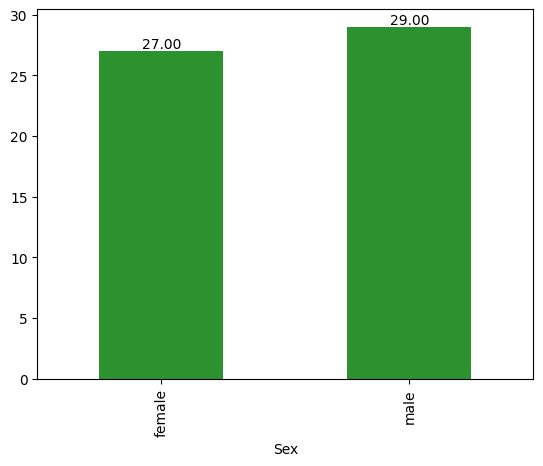

In [96]:
ax = train_data.groupby(['Sex'])['Age'].median().plot(kind='bar', color="#2C912FFF")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

There is a slight diffrence, but meaby there is something better, I will try class now:

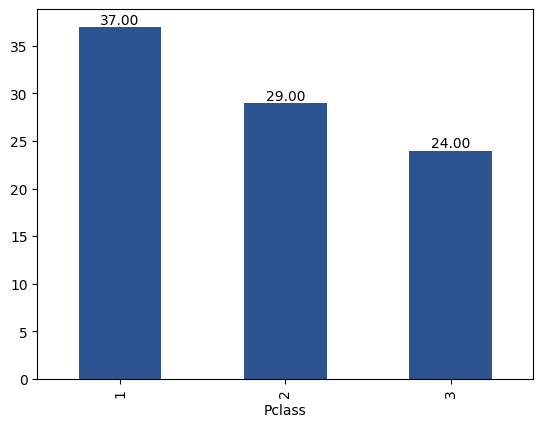

In [97]:
ax = train_data.groupby(['Pclass'])['Age'].median().plot(kind='bar', color="#2C5491FF")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

As we can see, there is far greater diffrence. I will now combine those two, creating more classes and better segregation.

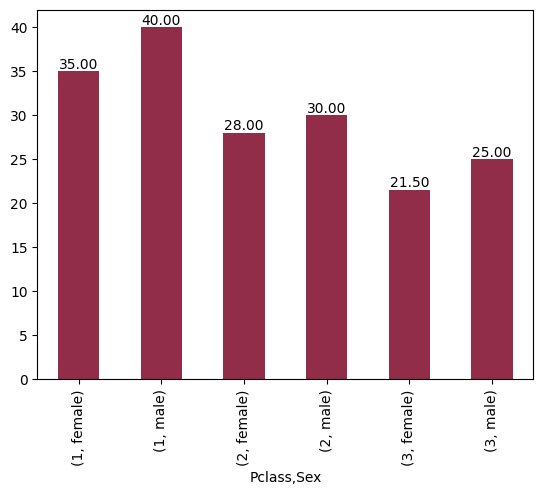

In [98]:
ax = train_data.groupby(['Pclass','Sex'])['Age'].median().plot(kind='bar', color="#912C49FF")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

For now I think this is enough for me to start filling missing values. I will also fill the same values to the test data, as it will be usefull in the ML part.

In [99]:
train_data['Age'].isna().sum()


np.int64(177)

In [100]:
#transform let's operate on each group, so here in every group I can get the mean and fill na with it
train_data['Age'] = train_data.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median(), ))

#creating global, and group medians that will be usefull in filling na in test data
medians = train_data.groupby(['Pclass', 'Sex'])['Age'].median()
global_median = train_data['Age'].median()


#function we will call in apply, it takes a key of a group and searches for it in the medians.
#If it is found, then the median that is connected to it fills missing values in this group
def fill_age_group(group):

    key = group.name #(Pclass, Sex)
    med = medians.get(key, global_median)

    return group['Age'].fillna(med)

#applying the function and testing if there are any missing values left in both of datasets
test_data['Age'] = test_data.groupby(['Pclass','Sex'], group_keys=False).apply(fill_age_group)

print(train_data['Age'].isnull().sum())
print(test_data['Age'].isnull().sum())

0
0


Now we can see both have beed filled. We can move to the next column with empty rows. In the cabin column we have info about the cabin number, if someone didn't have a cabin he has missing value. I think the most valueable information from this column is wether someone had a cabin or not. That is why I will change it so that this is the only information left. There are also 2 values missing in Embarked, we will fill them with the most used value(mode).

In [101]:
train_data['Cabin'] = train_data['Cabin'].notna().astype(int)
test_data['Cabin'] = test_data['Cabin'].notna().astype(int)

train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

test_data['Fare'] = test_data['Fare'].fillna(train_data['Fare'].median())

train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    int64  
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


In [102]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         418 non-null    float64
 9   Cabin        418 non-null    int64  
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 36.1 KB


Now that everything is filled I will drop Ticket column as it is useless info. Add age groups, get dummies for sex and embarked.

In [103]:
train_data = train_data.drop('Ticket',axis=1)
test_data = test_data.drop('Ticket', axis=1)

train_data['AgeGroup'] = pd.cut(train_data['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
test_data['AgeGroup'] = pd.cut(test_data['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])



Ok, everything I needed for the first paert is done. Now let's see the survival rates by class, sex, age group

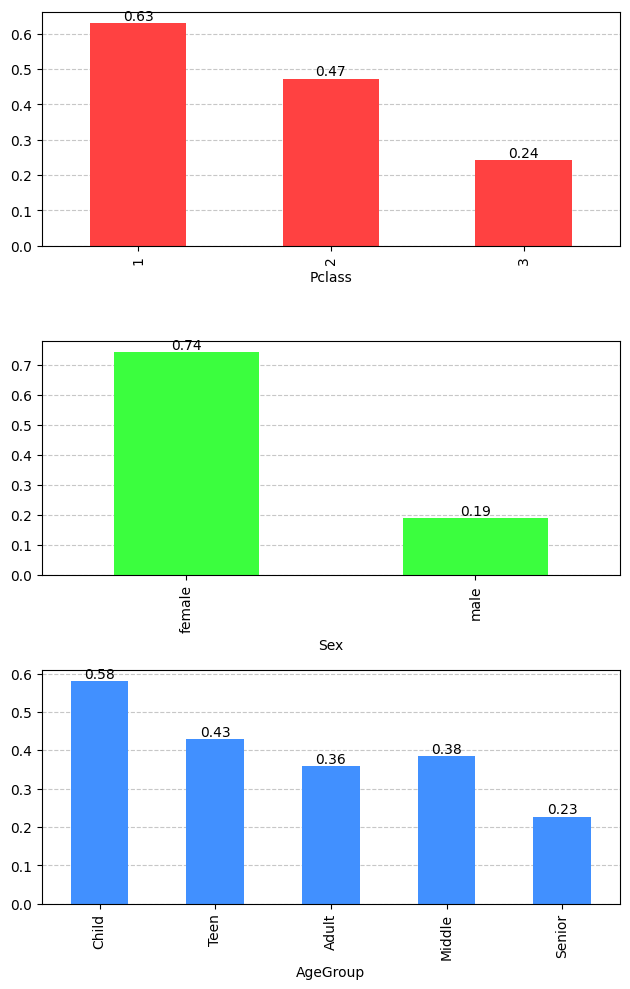

In [104]:
fig, axes = plt.subplots(3,1)
fig.set_figheight(10)


ax1 = train_data.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0], color="#FF4141")

ax2 = train_data.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color="#3BFE3E")

ax3 = train_data.groupby('AgeGroup')['Survived'].mean().plot(kind='bar', ax=axes[2], color="#4190FF")

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

plt.tight_layout()


We can see that the priority were women, high status, child. If you were a rich little girl your chances were the highest. The gender was the biggest factor, only 19% of men survived, but 74% of women. Next was class, if you had higher status, the chances you survived were higher. Then age group, Children and elderly were first to evacuate.

<Axes: xlabel='Age', ylabel='Density'>

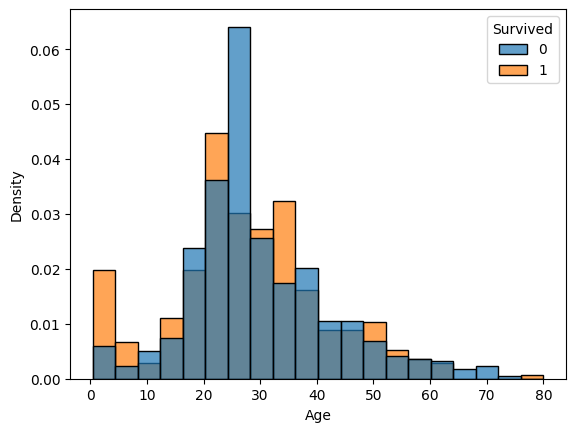

In [105]:
sns.histplot(data=train_data, x='Age', hue='Survived',
             stat='density', common_norm=False, bins=20, alpha=0.7)

We can see how the survival rate is spread across diffrent ages, biggest diffrence is around 25-27 years.

# Predicting survival rate

In this part i'm going to further change my data, so it can be fitted for a prediction model. First I'm going to change sex and embarked from categorical values to numerical, using get dummies function, also drop PassangerId, because it only distorts fitting. 

In [106]:
cat_col = ['Sex','Embarked']

train_dummies = pd.get_dummies(train_data[cat_col])
test_dummies = pd.get_dummies(test_data[cat_col])

train_data = train_data.join(train_dummies)
test_data =  test_data.join(test_dummies)

train_data = train_data.drop(['PassengerId','Sex','Embarked'], axis=1)
test_data = test_data.drop(['PassengerId','Sex','Embarked'], axis=1)



train_data.head(5)

,Survived,Pclass,Name,Age,SibSp,Parch,Fare,Cabin,AgeGroup,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,0,Adult,False,True,False,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,1,Middle,True,False,True,False,False
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,0,Adult,True,False,False,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,1,Adult,True,False,False,False,True
4,0,3,"Allen, Mr. William Henry",35.0,0,0,8.0500,0,Adult,False,True,False,False,True


Now I can, at least for now, drop Name and age group, I want to see how well could model perform with that kind of data.

In [107]:

train_data_1 = train_data.drop(['Name','AgeGroup'], axis= 1)
test_data_1 = test_data.drop(['Name','AgeGroup'], axis= 1)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

X = train_data_1.drop('Survived', axis=1)
y = train_data_1['Survived']

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(scores.mean(), scores.std())

0.7979787835038604 0.012316666803777802


This is quite a good result, although I didn't put much effort. What I could do, and what was recomended to me is getting the title from Name, and creating Alone column by summing SibSp and ParCh column to see if the person was traveling with anybody.

In [108]:
train_data_2 = train_data.drop('AgeGroup',axis= 1)
test_data_2 = test_data.drop('AgeGroup',axis= 1)


train_data_2['Title'] = train_data_2['Name'].str.extract(r' ([A-Za-z]+)\.')
test_data_2['Title'] = test_data_2['Name'].str.extract(r' ([A-Za-z]+)\.')

train_data_2['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

Now I will replace unique titles to just 'Rare' and drop Name column

In [109]:
train_data_2['Title'] = train_data_2['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona','Mlle','Mme','Ms'],
    'Rare')
train_data_2 = train_data_2.drop('Name', axis= 1)

test_data_2['Title'] = test_data_2['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona','Mlle','Mme','Ms'],
    'Rare')
test_data_2 = test_data_2.drop('Name', axis= 1)

train_data_2.head(4)

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title
0,0,3,22.0,1,0,7.2500,0,False,True,False,False,True,Mr
1,1,1,38.0,1,0,71.2833,1,True,False,True,False,False,Mrs
2,1,3,26.0,0,0,7.9250,0,True,False,False,False,True,Miss
3,1,1,35.0,1,0,53.1000,1,True,False,False,False,True,Mrs


Title column is working so now I will turn it into numerical values

In [110]:
title = pd.get_dummies(train_data_2['Title'])
train_data_2 = train_data_2.join(title)
train_data_2 = train_data_2.drop('Title', axis=1)

title = pd.get_dummies(test_data_2['Title'])
test_data_2 = test_data_2.join(title)
test_data_2 = test_data_2.drop('Title', axis=1)

train_data_2.head(3)

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Master,Miss,Mr,Mrs,Rare
0,0,3,22.0,1,0,7.2500,0,False,True,False,False,True,False,False,True,False,False
1,1,1,38.0,1,0,71.2833,1,True,False,True,False,False,False,False,False,True,False
2,1,3,26.0,0,0,7.9250,0,True,False,False,False,True,False,True,False,False,False


Now that title column is ready for model, I can add the family size and wether someone is alone or not. Those are two popular, and suggested options.

In [111]:
for df in [train_data_2, test_data_2]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

train_data_2 = train_data_2.drop(['SibSp','Parch'], axis=1)
test_data_2 = test_data_2.drop(['SibSp','Parch'], axis=1)


train_data_2.head(3)

,Survived,Pclass,Age,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Master,Miss,Mr,Mrs,Rare,FamilySize,IsAlone
0,0,3,22.0,7.2500,0,False,True,False,False,True,False,False,True,False,False,2,0
1,1,1,38.0,71.2833,1,True,False,True,False,False,False,False,False,True,False,2,0
2,1,3,26.0,7.9250,0,True,False,False,False,True,False,True,False,False,False,1,1


In [112]:
test_data_2.head(3)

,Pclass,Age,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Master,Miss,Mr,Mrs,Rare,FamilySize,IsAlone
0,3,34.5,7.8292,0,False,True,False,True,False,False,False,True,False,False,1,1
1,3,47.0,7.0000,0,True,False,False,False,True,False,False,False,True,False,2,0
2,2,62.0,9.6875,0,False,True,False,True,False,False,False,True,False,False,1,1


Now I will test some other models on the same data

In [113]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X = train_data_2.drop('Survived', axis=1)
y = train_data_2['Survived']

models = {
    'LogReg': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    'RF': RandomForestClassifier(n_estimators=100, random_state=0),
    'GBM': GradientBoostingClassifier(random_state=0),
}

for name, m in models.items():
    scores = cross_val_score(m, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

LogReg: 0.8294 ± 0.0229
RF: 0.8036 ± 0.0327
GBM: 0.8339 ± 0.0238


There is a lot of improvement, when the data was processed more. Now I can train model on the whole train data and test it.

In [114]:
X = train_data_2.drop('Survived', axis=1)
y = train_data_2['Survived']

gbm = GradientBoostingClassifier(    n_estimators=100,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,random_state=0)
gbm.fit(X, y)

X_test = test_data_2[X.columns]
preds = gbm.predict(X_test)

submission = pd.DataFrame({'PassengerId': pd.read_csv('data/test.csv')['PassengerId'], 'Survived': preds})
submission.to_csv('submission.csv', index=False)

In [115]:
X_final = X[['Pclass', 'Age', 'Fare', 'Cabin', 'Sex_female',
             'Mr', 'Master', 'FamilySize',
             'Embarked_C', 'Embarked_Q']]

gbm = GradientBoostingClassifier(    n_estimators=100,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,random_state=0)
gbm.fit(X_final, y)

X_test = test_data_2[X.columns]
preds = gbm.predict(X_test)

submission = pd.DataFrame({'PassengerId': pd.read_csv('data/test.csv')['PassengerId'], 'Survived': preds})
submission.to_csv('submission2.csv', index=False)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Embarked_S
- IsAlone
- Miss
- Mrs
- Rare
- ...
